# 00. Validating the calibration toolkit on simulated data

Before touching real data, we check that every tool recovers a truth we control.

Two fictional markets are simulated:

- **Calibrated**: logit(true probability) = logit(price)
- **Biased**: logit(true probability) = 1.3 × logit(price), a favorite-longshot bias

Outcomes within the same event are correlated through a Gaussian copula. This keeps each marginal probability exact while creating the within-cluster correlation that the cluster bootstrap is designed to handle.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
from pmcal.calibration import logit, murphy, calibration_regression, cluster_bootstrap, plot_reliability

## Simulation

A first version added a random event shock in logit space. It looked harmless but compressed probabilities towards 50%, so the "calibrated" market came out with β ≈ 0.91. The Gaussian copula avoids this distortion.

In [2]:
rng = np.random.default_rng(42)
N_EVENTS = 1500
RHO = 0.5  # latent correlation between markets of the same event


def simulate(true_beta):
    sizes = rng.integers(1, 11, N_EVENTS)         # 1 to 10 markets per event
    cluster = np.repeat(np.arange(N_EVENTS), sizes)
    p = rng.uniform(0.03, 0.97, len(cluster))
    q = 1 / (1 + np.exp(-true_beta * logit(p)))   # true marginal probability
    # Gaussian copula: outcomes of the same event are correlated, but
    # P(o = 1) stays exactly q (a shock in logit space would distort the marginals).
    z = np.sqrt(RHO) * rng.standard_normal(N_EVENTS)[cluster] \
        + np.sqrt(1 - RHO) * rng.standard_normal(len(cluster))
    o = (z < norm.ppf(q)).astype(int)
    return pd.DataFrame({"p": p, "o": o, "cluster": cluster})


def stats(df):
    a, b = calibration_regression(df.p, df.o)
    m = murphy(df.p, df.o)
    return {"alpha": a, "beta": b, "BS": m["BS"], "REL": m["REL"], "RES": m["RES"], "BSS": m["BSS"]}

## Estimation with cluster bootstrap

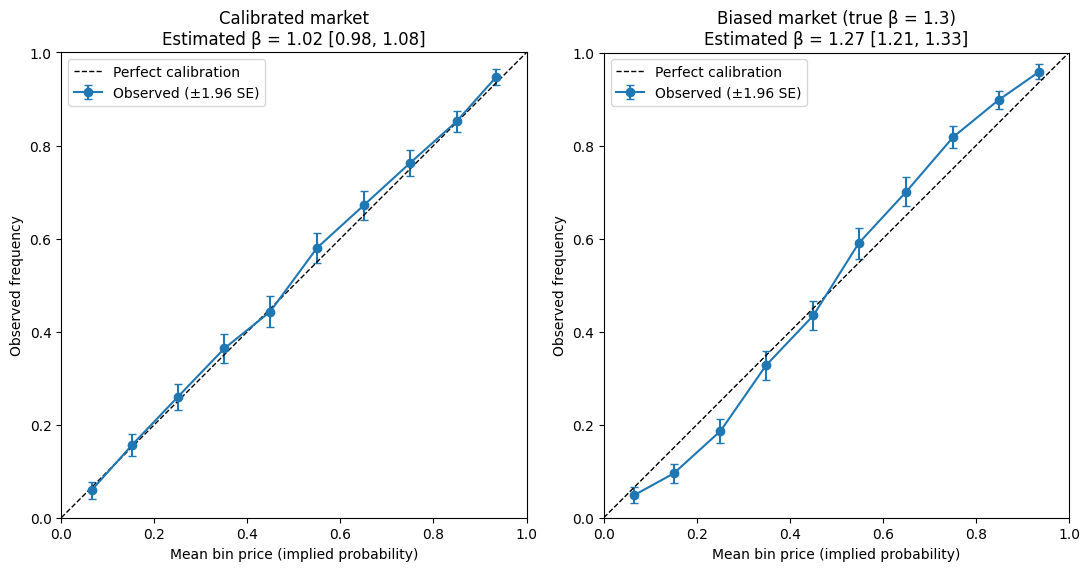


=== Calibrated market: 8328 markets, 1500 events ===
Cluster bootstrap:
       estimate  ci_low  ci_high
alpha    0.0566 -0.0261   0.1322
beta     1.0234  0.9765   1.0838
BS       0.1748  0.1700   0.1791
REL      0.0002  0.0001   0.0010
RES      0.0746  0.0703   0.0796
BSS      0.3008  0.2832   0.3199
CI width, cluster bootstrap / naive bootstrap:
  alpha: 1.6x
  beta : 1.1x
  BS   : 1.1x
  REL  : 1.2x

=== Biased market (true β = 1.3): 8297 markets, 1500 events ===
Cluster bootstrap:
       estimate  ci_low  ci_high
alpha    0.0396 -0.0461   0.1208
beta     1.2710  1.2142   1.3331
BS       0.1561  0.1521   0.1596
REL      0.0021  0.0016   0.0032
RES      0.0952  0.0910   0.1000
BSS      0.3754  0.3611   0.3909
CI width, cluster bootstrap / naive bootstrap:
  alpha: 1.4x
  beta : 1.1x
  BS   : 1.0x
  REL  : 1.0x


In [3]:
results = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, (name, true_beta) in zip(axes, [("Calibrated market", 1.0), ("Biased market (true β = 1.3)", 1.3)]):
    df = simulate(true_beta)
    ci_cluster = cluster_bootstrap(df, stats, "cluster", n_boot=500)
    # naive bootstrap: each observation is its own cluster
    ci_naive = cluster_bootstrap(df.assign(obs=np.arange(len(df))), stats, "obs", n_boot=500)
    results[name] = (len(df), ci_cluster, ci_naive)
    plot_reliability(ax, df.p, df.o, label="Observed (±1.96 SE)")
    b = ci_cluster.loc["beta"]
    ax.set_title(f"{name}\nEstimated β = {b.estimate:.2f} [{b.ci_low:.2f}, {b.ci_high:.2f}]")
    ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "reliability_simulation.png", dpi=150)
plt.show()

pd.set_option("display.float_format", "{:.4f}".format)
for name, (n, ci_cluster, ci_naive) in results.items():
    print(f"\n=== {name}: {n} markets, {N_EVENTS} events ===")
    print("Cluster bootstrap:")
    print(ci_cluster)
    print("CI width, cluster bootstrap / naive bootstrap:")
    for stat in ["alpha", "beta", "BS", "REL"]:
        w_c = ci_cluster.loc[stat, "ci_high"] - ci_cluster.loc[stat, "ci_low"]
        w_n = ci_naive.loc[stat, "ci_high"] - ci_naive.loc[stat, "ci_low"]
        print(f"  {stat:5s}: {w_c / w_n:.1f}x")

## Takeaways

- β is recovered in both cases, and the calibrated and biased markets are clearly distinguishable.
- REL stays tiny even with a strong bias: the regression slope is the more sensitive test.
- Clustering matters most for α. For β the effect is small here because prices within an event are drawn independently; on Kalshi, bracket markets have tightly linked prices, so the effect should be larger.